# Double Descent in Linear Models

## 1. Data generation

We generate a regression dataset with noisy linear labels:
`y = X·beta + noise`, with Gaussian inputs and Gaussian noise.

The ambient dimension `D` is the maximum number of available features.
Model complexity will then be controlled by using only the first `d`
columns of `X` (with `d` from 1 up to `D`): this is what lets us cross the
interpolation threshold `d = n` and observe double descent.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../src")

# core functions from our module
from double_descent import generate_data

# global seed for reproducibility
SEED = 0
rng = np.random.default_rng(SEED)

In [15]:
# global plotting style: modern, clean look (does not change any data)
import matplotlib as mpl

modern_palette = ["#2563eb", "#f59e0b", "#10b981", "#8b5cf6", "#ef4444"]

mpl.rcParams.update({
    # figure
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    # fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    # spines: keep only left and bottom
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#888888",
    "axes.linewidth": 0.8,
    # subtle grid behind the data
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#cccccc",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.4,
    # lines and markers
    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    # color cycle
    "axes.prop_cycle": mpl.cycler(color=modern_palette),
    # legend without box
    "legend.frameon": False,
    "legend.fontsize": 10,
})

In [2]:
# starting parameters
D = 200          # ambient dimension = maximum number of features
n_train = 40     # training set size (fixed)
n_test = 1000    # test set size (large, for an accurate error estimate)
noise_std = 0.5  # noise standard deviation

X_train, y_train, X_test, y_test, beta = generate_data(
    n_train, n_test, D, noise_std, rng
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("beta:   ", beta.shape, "| norm =", round(float(np.linalg.norm(beta)), 3))

X_train: (40, 200)
X_test:  (1000, 200)
beta:    (200,) | norm = 1.0


### Sanity check: are the labels really linear + noise?

We plot the observed label `y` against the true signal `X·beta`.
If the data model is correct, the points should lie along the diagonal,
with scatter caused only by the noise.

findfont: Failed to find font weight semibold, now using 700.


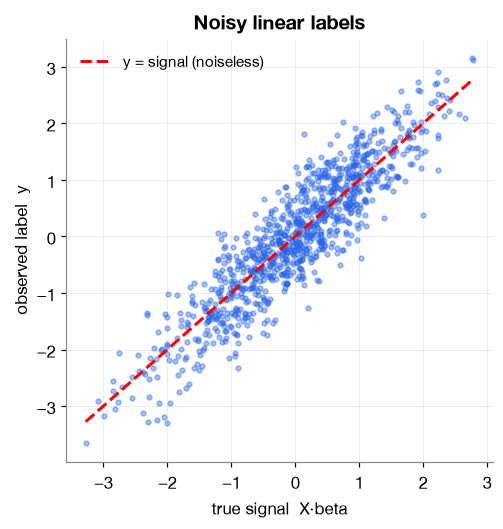

In [16]:
signal_test = X_test @ beta

plt.figure(figsize=(5, 5))
plt.scatter(signal_test, y_test, s=10, alpha=0.4)
plt.plot([signal_test.min(), signal_test.max()],
         [signal_test.min(), signal_test.max()],
         "r--", label="y = signal (noiseless)")
plt.xlabel("true signal  X·beta")
plt.ylabel("observed label  y")
plt.title("Noisy linear labels")
plt.legend()
plt.show()

## 2. Estimators (from scratch)

We implement two estimators by hand (no sklearn `.fit`):

- **Least squares** via the minimum-norm pseudoinverse, computed explicitly
  from the SVD. One formula covers both regimes (below and above the
  interpolation threshold).
- **Ridge regression** in closed form, `w = (X^T X + lam I)^(-1) X^T y`.

numpy is used only for the underlying matrix algebra.

In [4]:
from double_descent import fit_least_squares, fit_ridge, predict, mse

### 2.1 Sanity check

We fit least squares using the first `d` columns of `X` for three values of `d`:
one below the threshold, one at the threshold (`d = n_train`), one above it.

Expected behavior:
- `d` below threshold: non-zero train error, moderate test error;
- `d = n_train` (peak): the model interpolates (train ≈ 0) but test error
  and `||w||` blow up;
- `d` above threshold: still interpolates (train ≈ 0), but test error and
  `||w||` come back down. This is double descent already visible in 3 numbers.

In [5]:
# helper: fit least squares on the first d features, report train/test MSE and ||w||
def evaluate_ls(X_train, y_train, X_test, y_test, d):
    Xtr, Xte = X_train[:, :d], X_test[:, :d]
    w = fit_least_squares(Xtr, y_train)
    return mse(y_train, predict(Xtr, w)), mse(y_test, predict(Xte, w)), np.linalg.norm(w)

for d in [20, n_train, 80]:   # below threshold, at threshold, above threshold
    tr, te, wn = evaluate_ls(X_train, y_train, X_test, y_test, d)
    print(f"d = {d:3d} | train MSE = {tr:10.4e} | test MSE = {te:12.4f} | ||w|| = {wn:10.3f}")

d =  20 | train MSE = 5.0139e-01 | test MSE =       1.8934 | ||w|| =      0.930
d =  40 | train MSE = 5.2593e-29 | test MSE =     132.0439 | ||w|| =     11.464
d =  80 | train MSE = 5.7575e-30 | test MSE =       1.5929 | ||w|| =      0.807


### 2.2 Ridge: quick check

At the problematic complexity `d = n_train`, we compare least squares with
ridge (small `lam`). Ridge should give a much smaller test error and a much
smaller `||w||`: a first preview of how regularization removes the peak.

In [6]:
d = n_train
lam = 1e-2

w_ls = fit_least_squares(X_train[:, :d], y_train)
w_ridge = fit_ridge(X_train[:, :d], y_train, lam)

Xte = X_test[:, :d]
for name, w in [("least squares", w_ls), ("ridge (lam=1e-2)", w_ridge)]:
    print(f"{name:18s} | test MSE = {mse(y_test, predict(Xte, w)):12.4f} | ||w|| = {np.linalg.norm(w):10.3f}")

least squares      | test MSE =     132.0439 | ||w|| =     11.464
ridge (lam=1e-2)   | test MSE =      85.9013 | ||w|| =      9.233


## 3. Full experiment: vary the complexity d

We keep `n_train` fixed and let `d` range from 1 to `D`. For each `d` we fit
both estimators and record train MSE, test MSE and `||w||`, averaged over
several independent datasets (trials) to get smooth curves.

The grid of `d` values is denser around the interpolation threshold
`d = n_train`, where the curve changes most sharply.

In [7]:
from double_descent import run_experiment

# experiment configuration
n_trials = 50    # number of independent datasets to average over
lam = 1e-2       # ridge penalty (a single value for now)

# grid of complexities d, denser near the threshold d = n_train
d_grid = sorted(set(
    list(range(1, n_train - 5)) +          # below threshold
    list(range(n_train - 5, n_train + 6)) +  # dense around the threshold
    list(range(n_train + 6, D + 1, 4))     # above threshold (coarser)
))
print(f"{len(d_grid)} values of d, from {d_grid[0]} to {d_grid[-1]}")

84 values of d, from 1 to 198


In [8]:
# run the experiment (a few seconds)
results = run_experiment(
    d_grid=d_grid,
    n_train=n_train,
    n_test=n_test,
    n_features=D,
    noise_std=noise_std,
    n_trials=n_trials,
    lam=lam,
    seed=SEED,
)

print("done. keys:", list(results.keys()))

done. keys: ['ls_train', 'ls_test', 'ls_norm', 'ridge_train', 'ridge_test', 'ridge_norm']


### 3.1 Quick look at the test error curve

Before the full plots (next section), a quick line plot of the least-squares
test error confirms the experiment worked: we expect a peak right at
`d = n_train`, with lower error on both sides.

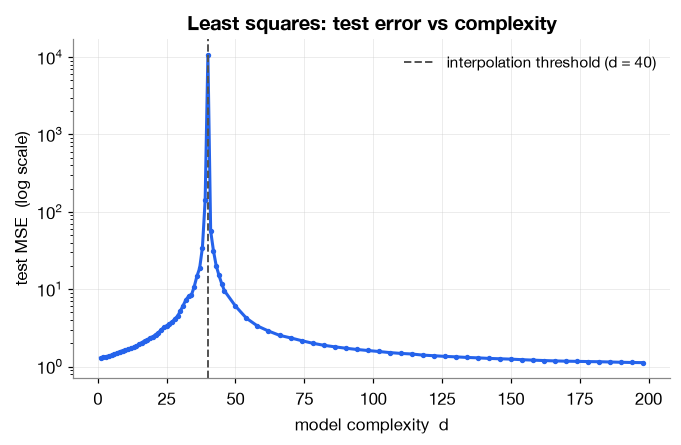

In [ ]:
d_arr = np.array(d_grid)

plt.figure(figsize=(7, 4))
plt.plot(d_arr, results["ls_test"], marker=".")
plt.axvline(n_train, color="#555555", linestyle="--", linewidth=1.3, label=f"interpolation threshold (d = {n_train})")
plt.yscale("log")   # log scale: the peak is very tall
plt.xlabel("model complexity  d")
plt.ylabel("test MSE  (log scale)")
plt.title("Least squares: test error vs complexity")
plt.legend()
plt.show()

## 4. Final plots for the report

We produce three figures and save them in the `figures/` folder:

1. **Train and test error** together: train error drops to zero at the
   interpolation threshold and stays there, while test error peaks.
2. **Solution norm** `||w||`: it explodes exactly at the threshold and then
   shrinks again — this is the mechanism behind the second descent.
3. **Ridge comparison**: sweeping the penalty `lam` shows the peak being
   progressively attenuated and eventually removed.

In [10]:
import os

# folder where the report figures are saved
os.makedirs("figures", exist_ok=True)

d_arr = np.array(d_grid)

### 4.1 Train and test error

The train curve is floored at a tiny value (1e-8) only for plotting: above
the threshold the train MSE reaches machine zero (~1e-29), which would
otherwise stretch the log axis. The message is that train error collapses
to zero at `d = n_train` and stays there, while test error peaks.

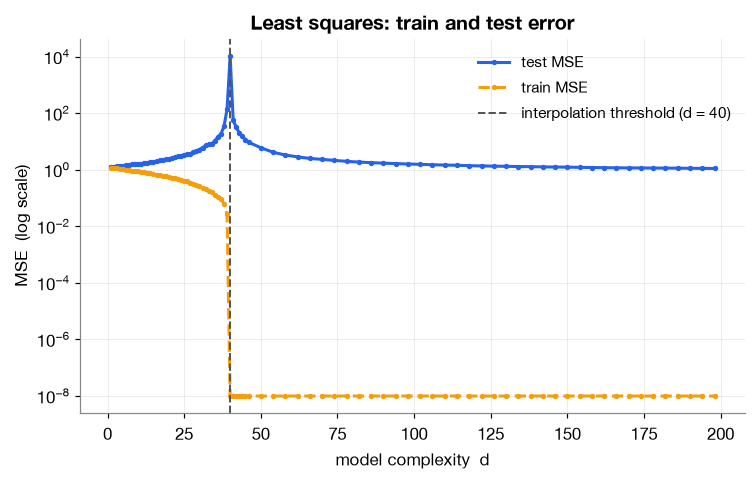

In [18]:
floor = 1e-8  # display only: train MSE hits machine zero past the threshold

plt.figure(figsize=(7, 4.5))
plt.plot(d_arr, results["ls_test"], marker=".", label="test MSE")
plt.plot(d_arr, np.maximum(results["ls_train"], floor), marker=".",
         linestyle="--", label="train MSE")
plt.axvline(n_train, color="#555555", linestyle="--", linewidth=1.3,
            label=f"interpolation threshold (d = {n_train})")
plt.yscale("log")
plt.xlabel("model complexity  d")
plt.ylabel("MSE  (log scale)")
plt.title("Least squares: train and test error")
plt.legend()
plt.tight_layout()
plt.savefig("figures/train_test.png", dpi=150)
plt.show()

### 4.2 Solution norm

We plot `||w||` against `d`. The norm peaks exactly at the interpolation
threshold (the smallest singular value of X goes to zero there, blowing up
the solution) and then decreases in the over-parameterized regime. The
shrinking norm is the inductive bias that drives the second descent.

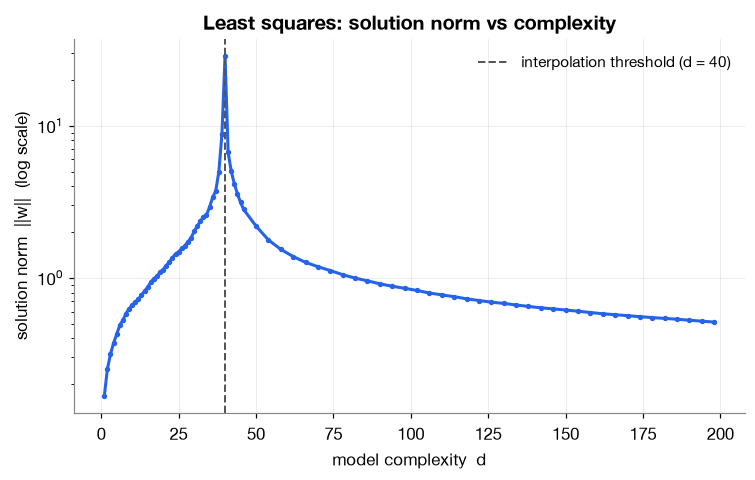

In [19]:
plt.figure(figsize=(7, 4.5))
plt.plot(d_arr, results["ls_norm"], marker=".")
plt.axvline(n_train, color="#555555", linestyle="--", linewidth=1.3,
            label=f"interpolation threshold (d = {n_train})")
plt.yscale("log")
plt.xlabel("model complexity  d")
plt.ylabel("solution norm  ||w||  (log scale)")
plt.title("Least squares: solution norm vs complexity")
plt.legend()
plt.tight_layout()
plt.savefig("figures/norm.png", dpi=150)
plt.show()

### 4.3 Ridge: attenuating the peak

We re-run the same experiment for a few ridge penalties `lam` and overlay
the test-error curves on top of the unregularized least-squares curve.
As `lam` grows, the interpolation peak shrinks and eventually disappears:
regularization "masks" double descent.

In [13]:
# sweep a few ridge penalties (same experiment, different lam)
# each run takes a few seconds
lam_values = [1e-3, 1e-2, 1e-1, 1.0]

ridge_curves = {}
for lam_v in lam_values:
    res = run_experiment(d_grid, n_train, n_test, D, noise_std,
                         n_trials, lam_v, SEED)
    ridge_curves[lam_v] = res["ridge_test"]

print("ridge sweep done")

ridge sweep done


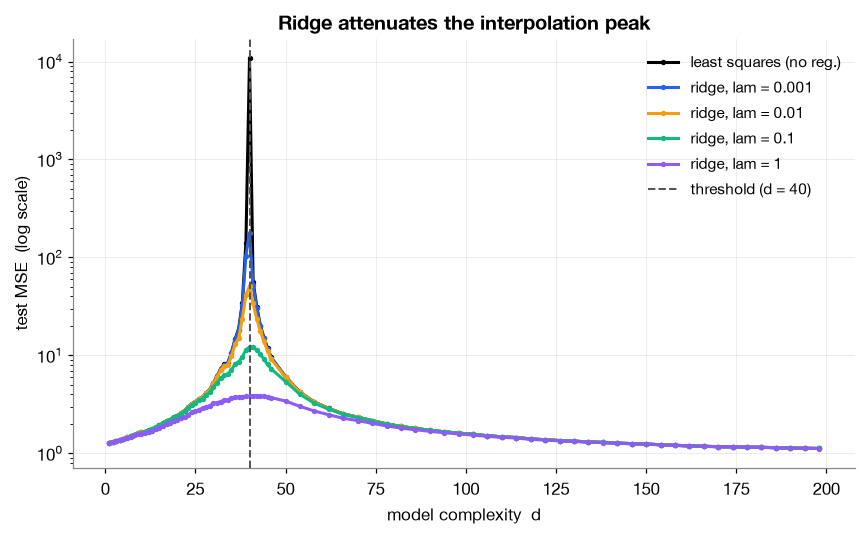

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(d_arr, results["ls_test"], marker=".", color="black",
         label="least squares (no reg.)")
for lam_v in lam_values:
    plt.plot(d_arr, ridge_curves[lam_v], marker=".", label=f"ridge, lam = {lam_v:g}")
plt.axvline(n_train, color="#555555", linestyle="--", linewidth=1.3,
            label=f"threshold (d = {n_train})")
plt.yscale("log")
plt.xlabel("model complexity  d")
plt.ylabel("test MSE  (log scale)")
plt.title("Ridge attenuates the interpolation peak")
plt.legend()
plt.tight_layout()
plt.savefig("figures/ridge.png", dpi=150)
plt.show()